In [8]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

U aproksimaciji izotermne atmosfere gustina opada sa visinom prema eksponencijalnom zakonu

$\rho = \rho_0e^{-h/H}$.

H je skala visina, koja predstavlja karakterističnu visinu na kojoj gustina atmosfere opadne e puta. Što je skala visina veća, gustina atmosfere opada sporije sa visinom.
Skala visina ne mora biti konstantna vrednost, odnosno gustina ne mora opadati sa istom stopom pri
površini i na većim visinama. 

Određivanje skale visina može da se svede na linearni fit zavisnosti $\ln\rho$ od visine h. Ukoliko je nagib dobijene prave jednak b, skala visina se određuje kao $H=-1/b$

Zadatak 1: Vertikalni profili na mreži geografske dužine i širine:
Za svaku tačku mreže:
1. Izračunati profil gustine od površine do najmanje 80 km visine.
2. Fitovati profil eksponencijalnim zakonom.
3. Odrediti skalu visina H.
4. Prikazati konturni plot H (long ,lat )

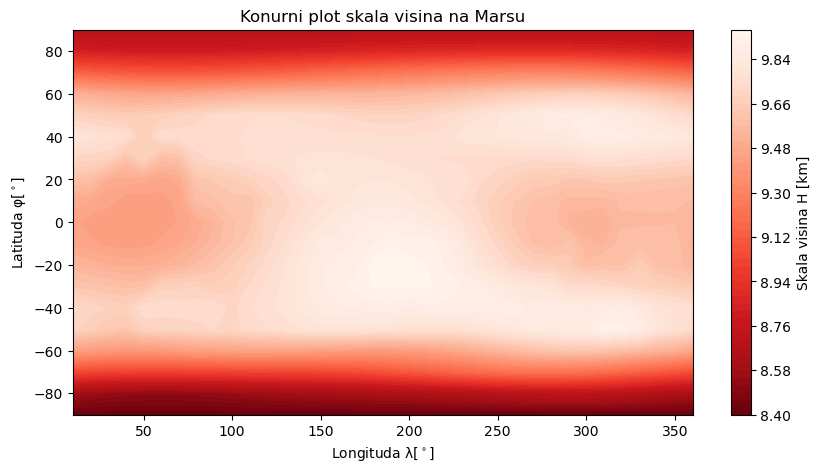

In [17]:
########### ucitavanje i prirprema podataka ############################
data = np.loadtxt("OUTPUT_1.txt", skiprows=1)   # cita se fajl

h = data[:,1]      # HgtMOLA - visina (0, 80, 5)
lat = data[:,2]    # LatPC   - latituda (-90, 90, 10)
lon = data[:,3]    # LonE    - longituda (0, 360, 10)
rho = data[:,4]    # Denkgm3 - gustina na svakoj lokaciji i visini

lokacije = np.unique(np.column_stack((lat, lon)), axis=0)  # tacke (i uklanja duplikate)

H_niz = []      # niz za rezultate - skala visine H
rho0_niz = []   # niz za rezultate - gustina pri povrsini 
lat_niz = []    # niz za latitude 
lon_niz = []    # niz za longitude

########### petlja za H na svakoj lokaciji ############################

for la, lo in lokacije:

    mask = (lat == la) & (lon == lo)  # filter

    h_prof = h[mask]
    rho_prof = rho[mask]

    idx = np.argsort(h_prof)          # sortiranje po visini

    h_prof = h_prof[idx]	          # sortiranje
    rho_prof = rho_prof[idx]          # sortiranje

    # linearni fit
    # ln(rho) = ln(pho0) - h/H 
    # y = b + mx
    
    x = h_prof
    y = np.log(rho_prof)

    m, b, _, _, _ = linregress(x, y)
    H = -1/m
    rho0 = np.exp(b)

    # popunjavanje nizova (liste)
    H_niz.append(H)
    rho0_niz.append(rho0)
    lat_niz.append(la)
    lon_niz.append(lo)
    
# porevod u array
H_niz = np.array(H_niz)
lat_niz = np.array(lat_niz)
lon_niz = np.array(lon_niz)
    
# pravljenje 2D mreže
lon_grid = np.unique(lon_niz)
lat_grid = np.unique(lat_niz)
H_grid = H_niz.reshape(len(lat_grid), len(lon_grid))
    

########### PLOTOVANJE ###########################################

plt.figure(figsize=(10,5))
plt.contourf(lon_grid, lat_grid, H_grid, levels=59, cmap='Reds_r')
plt.colorbar(label="Skala visina H [km]")
plt.xlabel("Longituda λ[$^\circ$]")
plt.ylabel("Latituda φ[$^\circ$]")
plt.title("Konurni plot skala visina na Marsu")
plt.show()


Dobijena mapa predstavlja konturni plot skala visina u toku jednog Zemaljskog dana, kada je na Marsku kraj leta (na severnoj hemisferi). Kako je Ls priblizno 180 stepeni, zagrejanost severne i juzne hemisfere je skoro jednaka, pa je i skala gustine ima gotovo simetricnu raspodelu. Vidljive sare na sredini posledica su razlicitih delova dana i razlicitih reljefnih karakteristika.   
Tamniji regioni oznacavaju nize skale visina (H), to jest predstavljaju mesta na kojima gustina atmosfere brze opada sa porastom visine. To znaci da je na takvim mestima atmosfera znatno koncentrisanija pri povrsini. Svetliji regioni oznacavaju mesta na kojima se gustina atmosfere sporije (u odnosu na tamne regije) podize pri porastu visine.  

Zadatak 2. Dnevne promene

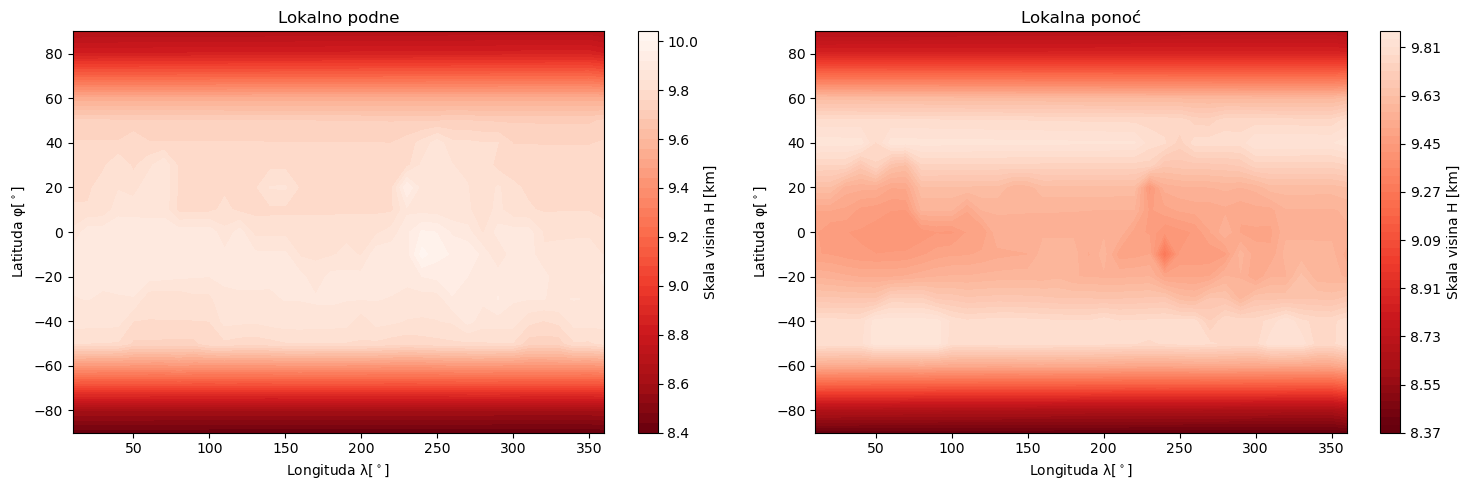

In [19]:
########### ucitavanje i prirprema podataka ############################

data_d = np.loadtxt("OUTPUT_jesen_podne.txt", skiprows=1)   # cita se fajl
data_n = np.loadtxt("OUTPUT_jesen_ponoc.txt", skiprows=1)   # cita se fajl

lat = data_d[:,2]    # LatPC   - latituda (-90, 90, 10)
lon = data_d[:,3]    # LonE    - longituda (0, 360, 10)
h = data_d[:,1]      # HgtMOLA - visina (0, 80, 5)

rho_d = data_d[:,4]    # Denkgm3 - gustina na svakoj lokaciji i visini
rho_n = data_n[:,4]    # Denkgm3 - gustina na svakoj lokaciji i visini

lokacije = np.unique(np.column_stack((lat, lon)), axis=0)  # tacke (i uklanja duplikate)

lat_niz = []      # niz za latitude 
lon_niz = []      # niz za longitude

H_niz_d = []      # niz za rezultate - skala visine H
H_niz_n = []      # niz za rezultate - skala visine H

rho0_niz_d = []   # niz za rezultate - gustina pri povrsini 
rho0_niz_n = []   # niz za rezultate - gustina pri povrsini 


########### petlja za H na svakoj lokaciji ############################

for la, lo in lokacije:

    mask = (lat == la) & (lon == lo)  # filter

    h_prof = h[mask]
    rho_prof_d = rho_d[mask]
    rho_prof_n = rho_n[mask]

    idx = np.argsort(h_prof)          # sortiranje po visini

    h_prof = h_prof[idx]	      # sortiranje
    rho_prof_d = rho_prof_d[idx]      # sortiranje
    rho_prof_n = rho_prof_n[idx]      # sortiranje

    # linearni fit
    # ln(rho) = ln(pho0) -  h/H 
    #    y    =     b    +  mx
    
    # podne:  
    x_d = h_prof
    y_d = np.log(rho_prof_d)

    m_d, b_d, _, _, _ = linregress(x_d, y_d)
    H_d = -1/m_d
    
    # ponoc:  
    x_n = h_prof
    y_n = np.log(rho_prof_n)

    m_n, b_n, _, _, _ = linregress(x_n, y_n)
    H_n = -1/m_n

    # popunjavanje nizova (liste):   
    H_niz_d.append(H_d)
    H_niz_n.append(H_n)
    
    lat_niz.append(la)
    lon_niz.append(lo)
    
# porevod u array
H_niz_d = np.array(H_niz_d)
H_niz_n = np.array(H_niz_n)
lat_niz = np.array(lat_niz)
lon_niz = np.array(lon_niz)
    
# pravljenje 2D mreže
lon_grid = np.unique(lon_niz)
lat_grid = np.unique(lat_niz)
H_grid_d = H_niz_d.reshape(len(lat_grid), len(lon_grid))
H_grid_n = H_niz_n.reshape(len(lat_grid), len(lon_grid))
    

########### PLOTOVANJE #######################################

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

vmin = min(H_grid_d.min(), H_grid_n.min())
vmax = max(H_grid_d.max(), H_grid_n.max())

cont1 = ax[0].contourf(lon_grid, lat_grid, H_grid_d, levels=50, cmap='Reds_r', vmin=vmin, vmax=vmax)
fig.colorbar(cont1, ax=ax[0], label="Skala visina H [km]")
ax[0].set_xlabel("Longituda λ[$^\circ$]")
ax[0].set_ylabel("Latituda φ[$^\circ$]")
ax[0].set_title("Lokalno podne")

cont2 = ax[1].contourf(lon_grid, lat_grid, H_grid_n, levels=50, cmap='Reds_r', vmin=vmin, vmax=vmax)
fig.colorbar(cont2, ax=ax[1], label="Skala visina H [km]")
ax[1].set_xlabel("Longituda λ[$^\circ$]")
ax[1].set_ylabel("Latituda φ[$^\circ$]")
ax[1].set_title("Lokalna ponoć")

plt.tight_layout()
plt.show()

Mozemo uociti znatnu razliku vrednosti H na odredjenim podrucjima. Regionalne strukture koje se vizuelno mogu izdvojiti predstavljaju upravo Marsove reljefne regije, medju kojima su najistaknutije provincija Tharsis i basen Hellas. Tu se desavaju najvece dnevne promene H. Na Marsu je ogromna temperaturna razlika u toku dana i noci. Zato nocu ohladjena atmosfera "pada", zbog cega se vrednost H smanjuje.

Zadatak 3. Sezonske promene

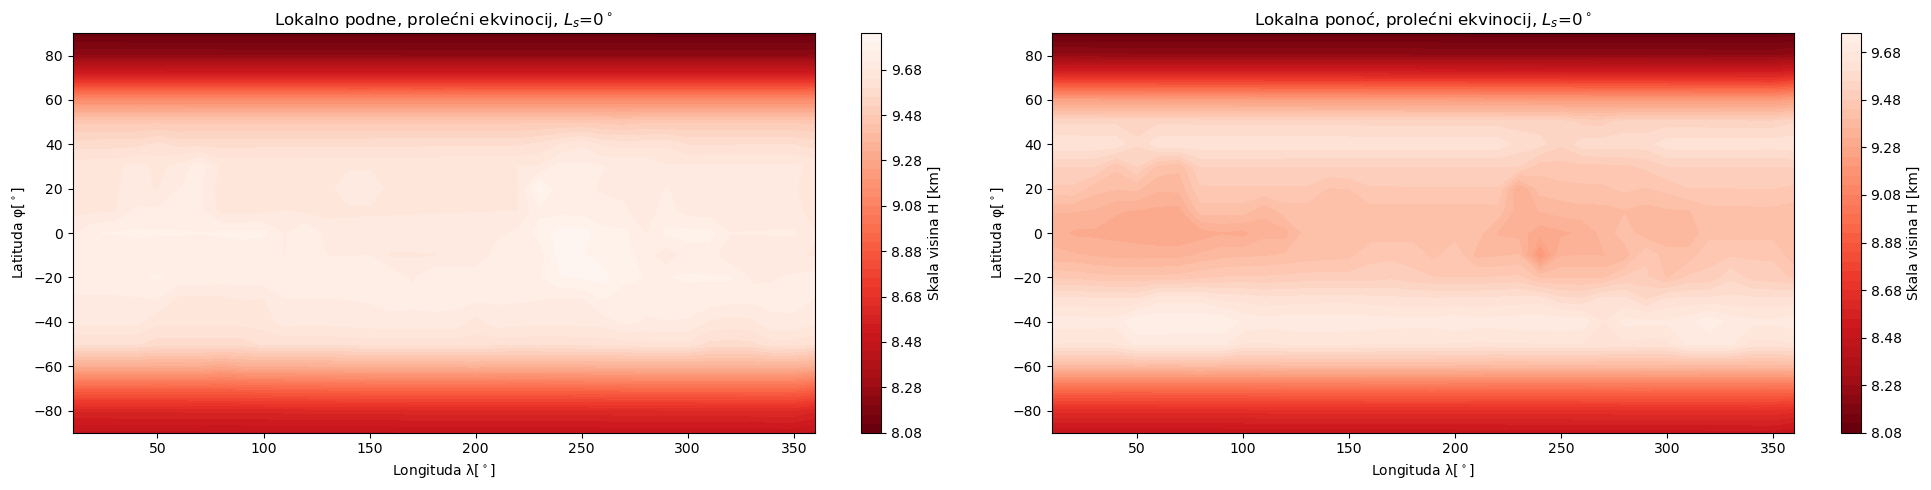

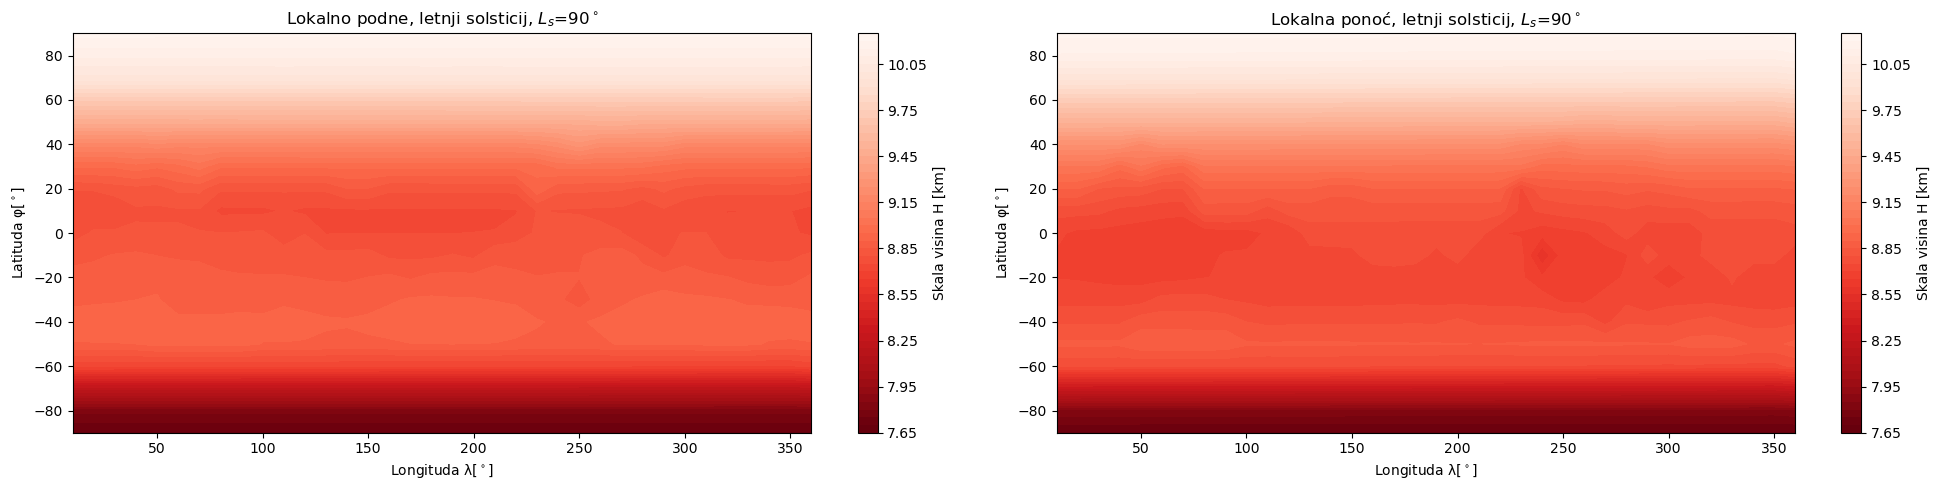

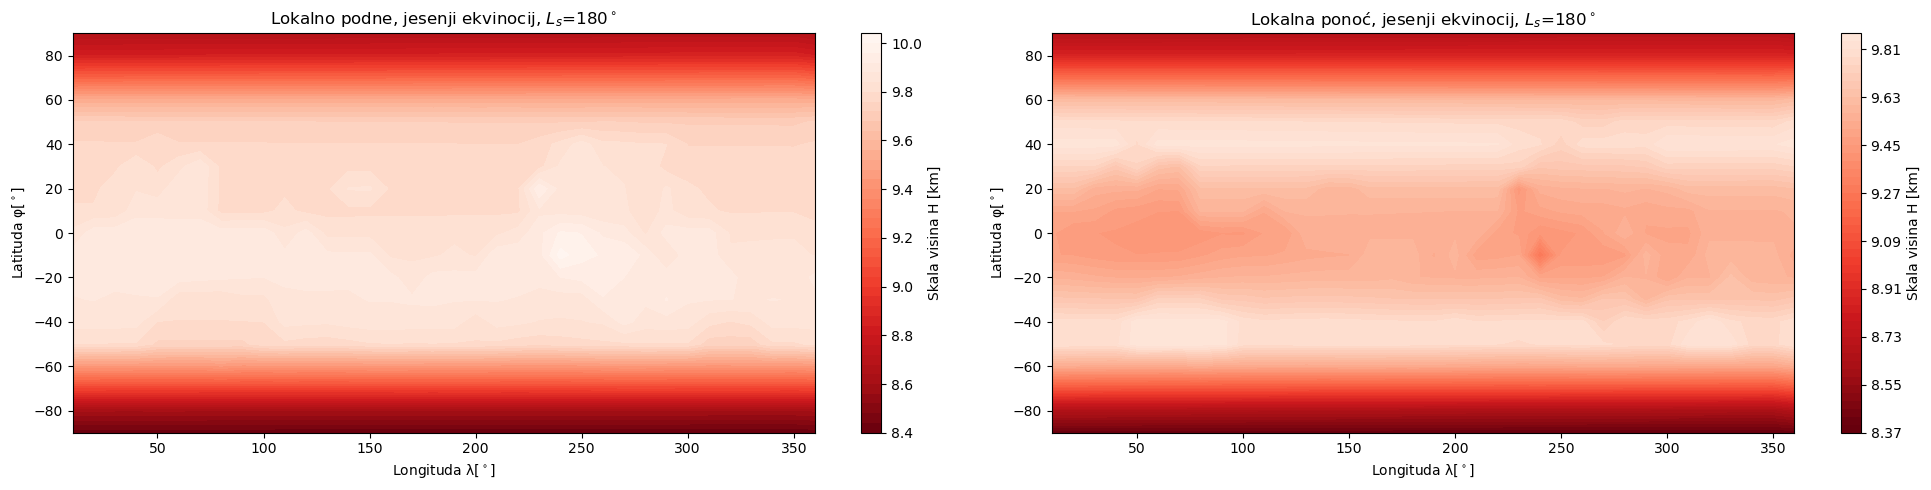

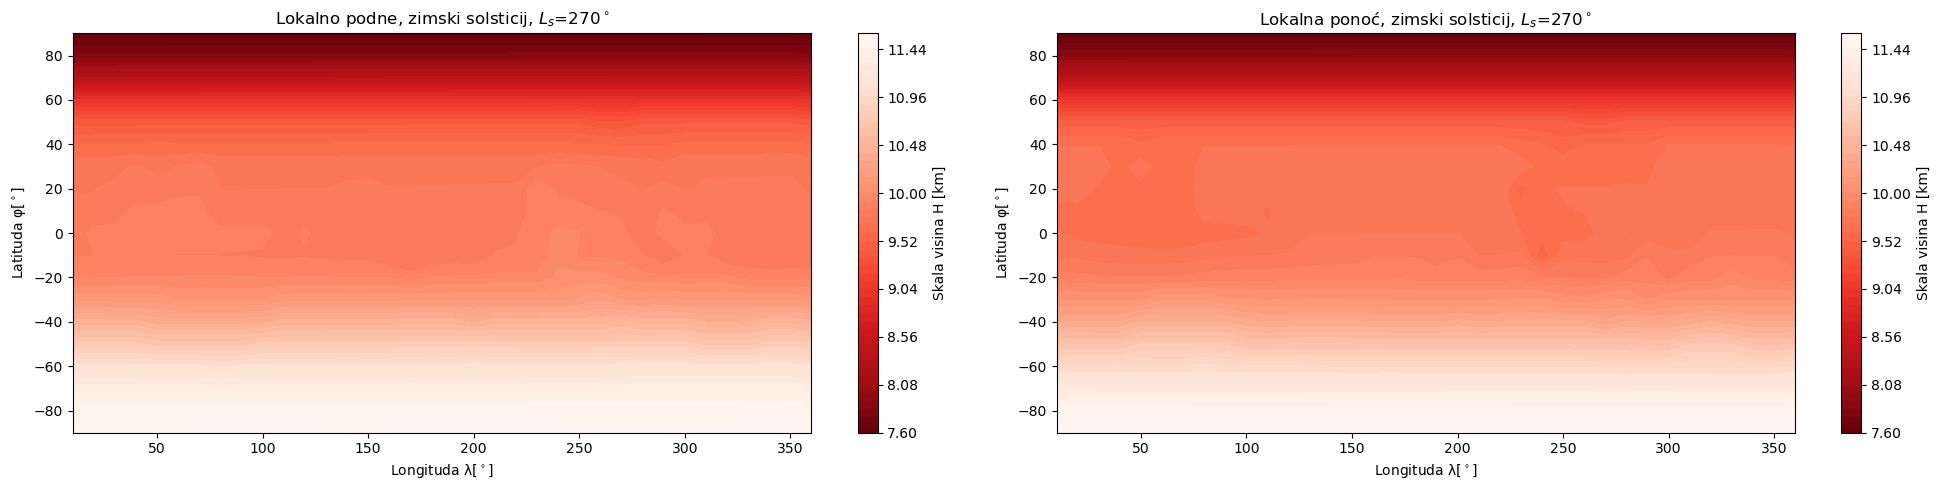

In [11]:
##############################################################

def izracunaj_H(data):

    # ucitavanje podataka iz data tabele (potebne samo 4 kolone):
    lat = data[:, 2]
    lon = data[:, 3]
    h   = data[:, 1]
    rho = data[:, 4]
    
    # pravljenje mreze:
    lokacije = np.unique(np.column_stack((lat, lon)), axis=0)

    # prazni nizovi: 
    H_niz = []
    lat_niz = []
    lon_niz = []

    # petlja koja racuna H za svaku tacku mreze
    for la, lo in lokacije:
	
	# maska sluzi da iz tru/false niza izvucemo tacno potrebnu tacku (la, lon)
        mask = (lat == la) & (lon == lo)

        h_prof = h[mask]
        rho_prof = rho[mask]

        idx = np.argsort(h_prof)
        
        # sortiramo po visinama 
        h_prof = h_prof[idx]
        rho_prof = rho_prof[idx]
        
        # linearni fit 
        y = np.log(rho_prof)
        m, b, _, _, _ = linregress(h_prof, y)
        H = -1 / m
	
	# dodajemo u niz da bismo plotovali
        H_niz.append(H)
        lat_niz.append(la)
        lon_niz.append(lo)
        
    # pravimo array
    H_niz = np.array(H_niz)
    lat_niz = np.array(lat_niz)
    lon_niz = np.array(lon_niz)

    lon_grid = np.unique(lon_niz)
    lat_grid = np.unique(lat_niz)

    H_grid = H_niz.reshape(len(lat_grid), len(lon_grid))

    # vracaju se nizovi za plotovanje
    return H_grid, lon_grid, lat_grid
    
##############################################################    
    
def plot_sezona(fajl_podne, fajl_ponoc, sezona):

    # iz fajlova se izvlace linije koje se smestaju u data tabelu
    data_d = np.loadtxt(fajl_podne, skiprows=1)
    data_n = np.loadtxt(fajl_ponoc, skiprows=1)

    # koristi se funkcija za racunanje
    H_grid_d, lon_grid, lat_grid = izracunaj_H(data_d)
    H_grid_n, _, _ = izracunaj_H(data_n)
    
    # ovo radimo da bi na razlicitim plotovima 
    # iste boje oznacavale istu vrednosti
    vmin = min(H_grid_d.min(), H_grid_n.min())
    vmax = max(H_grid_d.max(), H_grid_n.max())

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))

    cont1 = ax[0].contourf(lon_grid, lat_grid, H_grid_d, levels=50, cmap='Reds_r', vmin=vmin, vmax=vmax)
    fig.colorbar(cont1, ax=ax[0], label="Skala visina H [km]")

    ax[0].set_title(f"Lokalno podne, {sezona}")
    ax[0].set_xlabel("Longituda λ[$^\circ$]")
    ax[0].set_ylabel("Latituda φ[$^\circ$]")

    cont2 = ax[1].contourf(lon_grid, lat_grid, H_grid_n, levels=50, cmap='Reds_r', vmin=vmin, vmax=vmax)
    fig.colorbar(cont2, ax=ax[1], label="Skala visina H [km]")

    ax[1].set_title(f"Lokalna ponoć, {sezona}")
    ax[1].set_xlabel("Longituda λ[$^\circ$]")
    ax[1].set_ylabel("Latituda φ[$^\circ$]")

    plt.tight_layout()
    plt.show()
   
##############################################################   

plot_sezona("OUTPUT_prolece_podne.txt", "OUTPUT_prolece_ponoc.txt", "prolećni ekvinocij, $L_s$=0$^\circ$" )        
    
plot_sezona("OUTPUT_leto_podne.txt", "OUTPUT_leto_ponoc.txt", "letnji solsticij, $L_s$=90$^\circ$")

plot_sezona("OUTPUT_jesen_podne.txt","OUTPUT_jesen_ponoc.txt","jesenji ekvinocij, $L_s$=180$^\circ$")

plot_sezona("OUTPUT_zima_podne.txt","OUTPUT_zima_ponoc.txt", "zimski solsticij, $L_s$=270$^\circ$")

Tokom letnjeg solsticija, kada je severna strana okrenuta suncu, topla atmosfera se uzdize i povecava se H, a na juznoj hemisferi je manja H vrednost. Oko zimskog solsticija situacija je obrnuta. Prolecni i jesenji ekvinocij desavaju se kada su severna i juzna polulopta jednako osuncane. Zbog toga se javlja simetrija. Tada su polovi hladniji (manje H), a oko ekvatora je toplije (vece H).  

Zadatak 4. Analiza u koordinatama geografska širina – solarna longitudina:


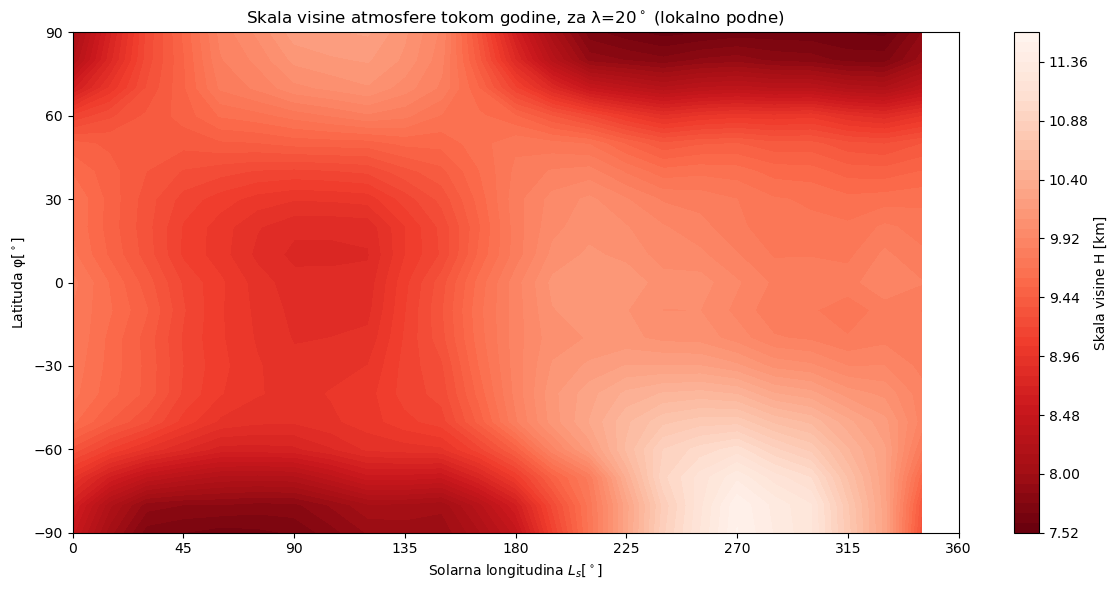

In [12]:
############# racunanje H za dati OUTPUT fajl ###############################
def izracunaj_H(data):

    # potrebne kolone
    lat = data[:,2]      # LatPC
    h = data[:,1]        # HgtMOLA
    rho = data[:,4]      # gustina

    latitude = np.unique(lat)
    H_niz = []

    # racunanje H za svaku latitudu
    for la in latitude:

        # izdvajanje jednog vertikalnog profila
        mask = (lat == la)

        h_prof = h[mask]
        rho_prof = rho[mask]

        # sortiranje po visini
        idx = np.argsort(h_prof)
        h_prof = h_prof[idx]
        rho_prof = rho_prof[idx]

        # linearni fit:
        # ln(rho)=ln(rho0)-h/H
        # y=b+m*x
        
        y = np.log(rho_prof)
        m, b, _, _, _ = linregress(h_prof, y)
        H = -1/m
        H_niz.append(H)

    return latitude, np.array(H_niz)


############ Ucitavanje svih Ls vrednosti ###################################
Ls_vrednosti = np.arange(0,360,15)
H_sve = []                              # niz za plotovanje 

for Ls in Ls_vrednosti:

    fajl = f"OUTPUT_Ls{Ls}.txt"         # OUTPUT_Ls*.txt
    data = np.loadtxt(fajl, skiprows=1)
    lat, H = izracunaj_H(data)          # poziva se funkcija
    H_sve.append(H)                     # dodajemo u niz

H_sve = np.array(H_sve)                 # pretvaranje u matricu

Ls_grid, lat_grid = np.meshgrid(Ls_vrednosti, lat)  # mreza


################# Plot H(phi,Ls) ###########################################
plt.figure(figsize=(12,6))

kontura = plt.contourf(Ls_grid, lat_grid, H_sve.T, levels=50, cmap="Reds_r")

plt.colorbar(kontura, label="Skala visine H [km]")
plt.xlabel("Solarna longitudina $L_s$[$^\circ$]")
plt.ylabel("Latituda φ[$^\circ$]")
plt.title("Skala visine atmosfere tokom godine, za λ=20$^\circ$ (lokalno podne)")
plt.xticks(np.arange(0,361,45))
plt.yticks(np.arange(-90,91,30))
plt.tight_layout()

plt.show()

Kako se menja H  u toku godine na jednoj izabranoj longitudi, koja ne prolazi kroz neko podrucje ekstremnih uslova (grafik iznad)

Zadatak 5. Poredjenje severne i juzne hemisfere:

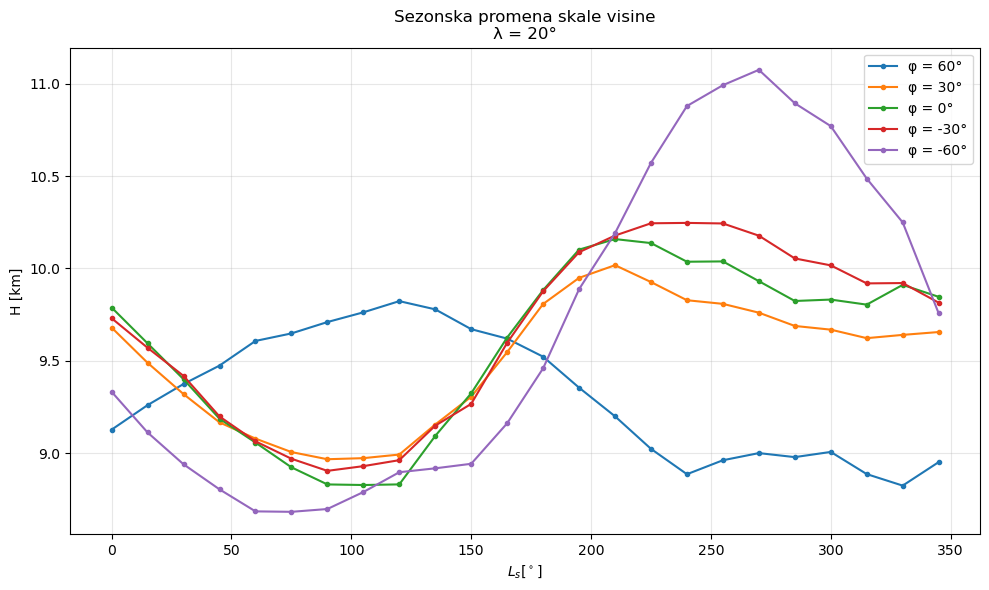

In [13]:
############# racunanje H za dati OUTPUT fajl ###############################
def izracunaj_H(data):

    lat = data[:,2]
    h = data[:,1]
    rho = data[:,4]

    latitude = np.unique(lat)

    H_niz = []

    for la in latitude:

        mask = (lat == la)

        h_prof = h[mask]
        rho_prof = rho[mask]

        idx = np.argsort(h_prof)

        h_prof = h_prof[idx]
        rho_prof = rho_prof[idx]

        m, b, _, _, _ = linregress(h_prof, np.log(rho_prof))
        H = -1/m
        H_niz.append(H)

    return latitude, np.array(H_niz)

############ Ucitavanje svih Ls vrednosti ###################################
Ls_vrednosti = np.arange(0, 360, 15)

trazene_lat = [60, 30, 0, -30, -60]
rezultati = {
    60: [],
    30: [],
    0: [],
    -30: [],
    -60: []
}

for Ls in Ls_vrednosti:

    fajl = f"OUTPUT_Ls{Ls}.txt"

    data = np.loadtxt(fajl, skiprows=1)

    lat, H = izracunaj_H(data)

    for la in trazene_lat:

        idx = np.where(lat == la)[0][0]

        rezultati[la].append(H[idx])

################# Plot H(phi,Ls) ###########################################
plt.figure(figsize=(10,6))

for la in trazene_lat:
    plt.plot(Ls_vrednosti, rezultati[la], marker='.', label=f"φ = {la}°")

plt.xlabel("$L_s[^\circ]$")
plt.ylabel("H [km]")
plt.title( "Sezonska promena skale visine\n" "λ = 20°")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Izabrano je nekoliko karakteriticnih latituda: ekvator i po dve sa svake hemisfere. Analiziramo sezonsku promenu skala visine. Vidimo da se najveca amplituda nalazi na juznoj polulopti, a narocito je izrazena visoka vrednost H tokom zimskog solsticija (kada je na jugu leto). Reljef na Marsu ovo objasnjava. Na juznoj polulopti nalaze se velike i izrazene geografske regije, sto utice na gustinu atmosfere. Zbog toga se javlja asimetrija izmedju hemisfera. 

Zadatak 6. Analiza kvaliteta eksponencijalnog modela:

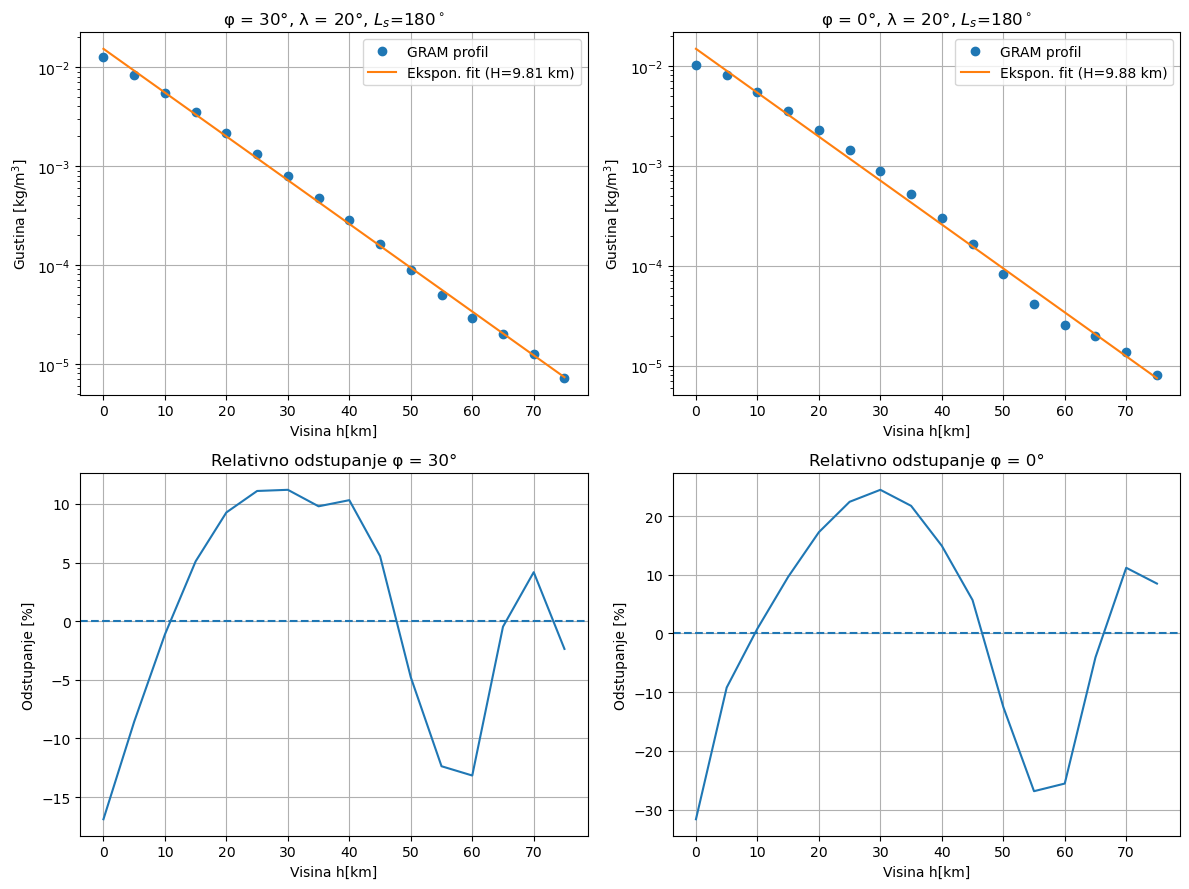

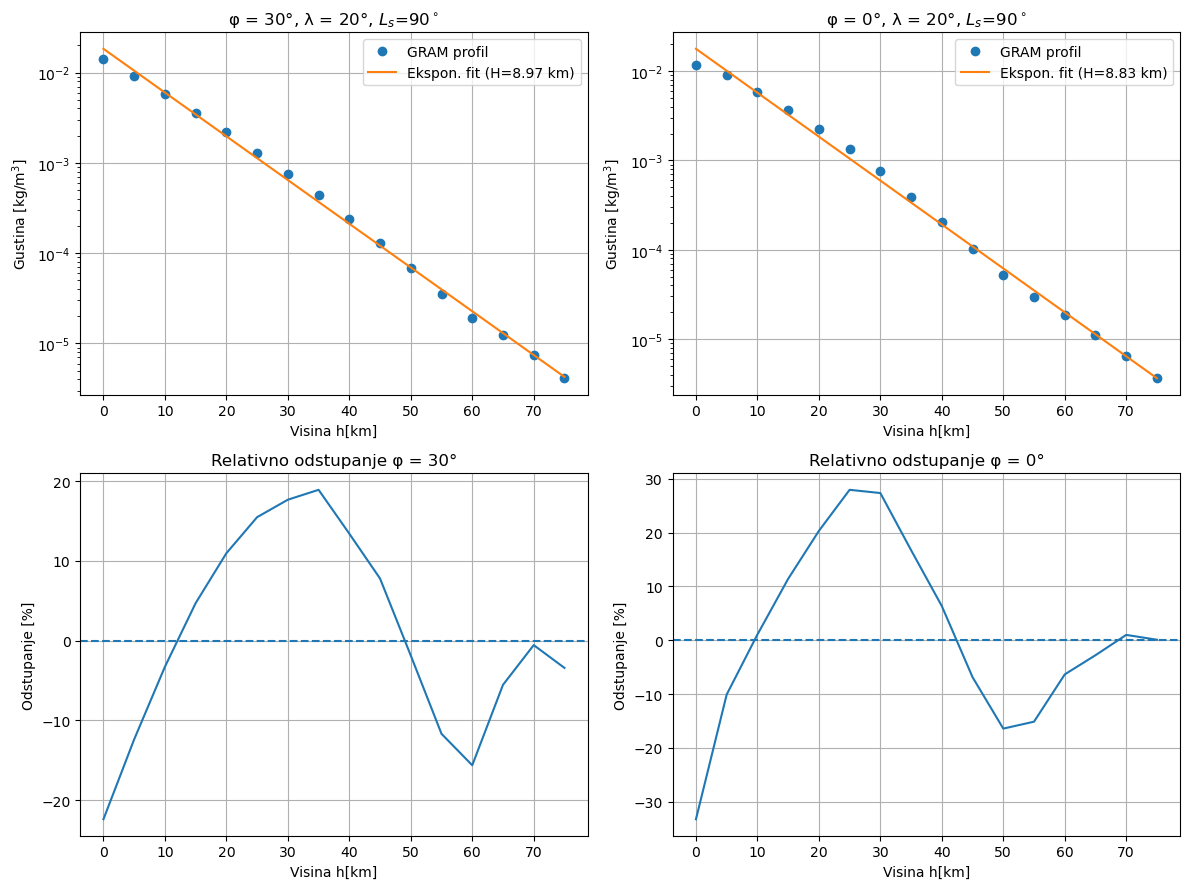

In [14]:
########## FUNKCIJA ZA PROFIL I FIT #######################
def profil_i_fit(data, lat_izbor, lon_izbor):

    lat = data[:,2]
    lon = data[:,3]
    h = data[:,1]
    rho = data[:,4]

    mask = (lat == lat_izbor) & (lon == lon_izbor)

    h_prof = h[mask]
    rho_prof = rho[mask]

    idx = np.argsort(h_prof)

    h_prof = h_prof[idx]
    rho_prof = rho_prof[idx]

    # linearni fit:
    # ln(rho) = ln(rho0) - h/H
    m, b, _, _, _ = linregress(h_prof, np.log(rho_prof))
    H = -1/m
    rho0 = np.exp(b)

    rho_fit = rho0 * np.exp(-h_prof/H)   # exp model
    odstupanje = (rho_prof - rho_fit) / rho_fit * 100  # rel odstupanje

    return h_prof, rho_prof, rho_fit, odstupanje, H


############### PODACI JESEN #####################################
data = np.loadtxt("OUTPUT_Ls180.txt", skiprows=1)     # jesen

# RACUNANJE ZA DVE LOKACIJE
h30, rho30, fit30, odst30, H30 = profil_i_fit(data, 30, 20)
h0, rho0, fit0, odst0, H0 = profil_i_fit(data, 0, 20)


##################### CRTANJE  JESEN #############################
fig, ax = plt.subplots(2, 2, figsize=(12,9))

# Gustina + fit, lat 30

ax[0,0].semilogy(h30, rho30, 'o', label="GRAM profil")
ax[0,0].semilogy(h30, fit30, '-', label=f"Ekspon. fit (H={H30:.2f} km)")
ax[0,0].set_title("φ = 30°, λ = 20°, $L_s$=180$^\circ$")
ax[0,0].set_xlabel("Visina h[km]")
ax[0,0].set_ylabel(r"Gustina [kg/m$^3$]")
ax[0,0].grid()
ax[0,0].legend()


# Gustina + fit, lat 0

ax[0,1].semilogy(h0, rho0, 'o', label="GRAM profil")
ax[0,1].semilogy(h0, fit0, '-', label=f"Ekspon. fit (H={H0:.2f} km)")
ax[0,1].set_title("φ = 0°, λ = 20°, $L_s$=180$^\circ$")
ax[0,1].set_xlabel("Visina h[km]")
ax[0,1].set_ylabel(r"Gustina [kg/m$^3$]")
ax[0,1].grid()
ax[0,1].legend()


# Odstupanje, lat 30

ax[1,0].plot(h30, odst30)
ax[1,0].axhline(0, linestyle="--")
ax[1,0].set_title("Relativno odstupanje φ = 30°")
ax[1,0].set_xlabel("Visina h[km]")
ax[1,0].set_ylabel("Odstupanje [%]")
ax[1,0].grid()


# Odstupanje, lat 0

ax[1,1].plot(h0, odst0)
ax[1,1].axhline(0, linestyle="--")
ax[1,1].set_title("Relativno odstupanje φ = 0°")
ax[1,1].set_xlabel("Visina h[km]")
ax[1,1].set_ylabel("Odstupanje [%]")
ax[1,1].grid()

plt.tight_layout()
plt.show()

############### PODACI LETO #####################################
data = np.loadtxt("OUTPUT_Ls90.txt", skiprows=1)     # jesen

# RACUNANJE ZA DVE LOKACIJE
h30, rho30, fit30, odst30, H30 = profil_i_fit(data, 30, 20)
h0, rho0, fit0, odst0, H0 = profil_i_fit(data, 0, 20)


##################### CRTANJE  LETO #############################
fig, ax = plt.subplots(2, 2, figsize=(12,9))

# Gustina + fit, lat 30

ax[0,0].semilogy(h30, rho30, 'o', label="GRAM profil")
ax[0,0].semilogy(h30, fit30, '-', label=f"Ekspon. fit (H={H30:.2f} km)")
ax[0,0].set_title("φ = 30°, λ = 20°, $L_s$=90$^\circ$")
ax[0,0].set_xlabel("Visina h[km]")
ax[0,0].set_ylabel(r"Gustina [kg/m$^3$]")
ax[0,0].grid()
ax[0,0].legend()


# Gustina + fit, lat 0

ax[0,1].semilogy(h0, rho0, 'o', label="GRAM profil")
ax[0,1].semilogy(h0, fit0, '-', label=f"Ekspon. fit (H={H0:.2f} km)")
ax[0,1].set_title("φ = 0°, λ = 20°, $L_s$=90$^\circ$")
ax[0,1].set_xlabel("Visina h[km]")
ax[0,1].set_ylabel(r"Gustina [kg/m$^3$]")
ax[0,1].grid()
ax[0,1].legend()


# Odstupanje, lat 30

ax[1,0].plot(h30, odst30)
ax[1,0].axhline(0, linestyle="--")
ax[1,0].set_title("Relativno odstupanje φ = 30°")
ax[1,0].set_xlabel("Visina h[km]")
ax[1,0].set_ylabel("Odstupanje [%]")
ax[1,0].grid()


# Odstupanje, lat 0

ax[1,1].plot(h0, odst0)
ax[1,1].axhline(0, linestyle="--")
ax[1,1].set_title("Relativno odstupanje φ = 0°")
ax[1,1].set_xlabel("Visina h[km]")
ax[1,1].set_ylabel("Odstupanje [%]")
ax[1,1].grid()

plt.tight_layout()
plt.show()

Grafici prikazuju originalni profil gustine i eksponencijalni fit, a zastim i relativno odstupanje između modela i fita, na razlicitim latitudama i tokom razlicitih sezona.

Najveca odstupanja se svakako javljaju pri malim visinama, blizu tla, kao i na visinama od oko 30km. Moze se takodje primetiti da sezona igra znacajnu ulogu: aproksimacija je tacnija tokom jeseni i proleca. Vidljivo je i da su veca odstupanja oko ekvatora, a manja kako se od njega udaljavamo.